# Insurance Costs Analysis

This project explores how demographic and health-related variables relate to medical insurance charges. I use exploratory visualizations first, then compare linear and polynomial regression models with MSE and R-squared so the final model choice is tied to predictive error and explained variance.

## Overview

The goal is to understand which factors are most associated with insurance costs and to build a regression model that predicts charges on new data.

In [92]:
from plotnine import *
import numpy as np
import pandas as pd

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## Data Preparation

I begin by handling the insurance dataset, reviewing summary statistics, and removing missing values and duplicate rows to clean dataset before comparing features.

In [93]:
df = pd.read_csv("insurance_costs_1 (1).csv")
df.copy()

df.describe()
df = df.dropna()
df = df.drop_duplicates()
df.head()

,age,sex,bmi,smoker,region,charges
0,19,female,27.900,yes,southwest,16884.92400
1,33,male,22.705,no,northwest,21984.47061
2,32,male,28.880,no,northwest,3866.85520
3,31,female,25.740,no,southeast,3756.62160
4,60,female,25.840,no,northwest,28923.13692


## Exploratory Data Analysis

### Individuals who smoke have insurance costs under 40,000 compared to 10,000 for non-smokers

I chose a boxplot to see whether an there is an association between higher costs and smoker status and visually represented the smoker status distribution, median, and spread of costs for smokers and non-smokers to see whether there was a noticable difference.

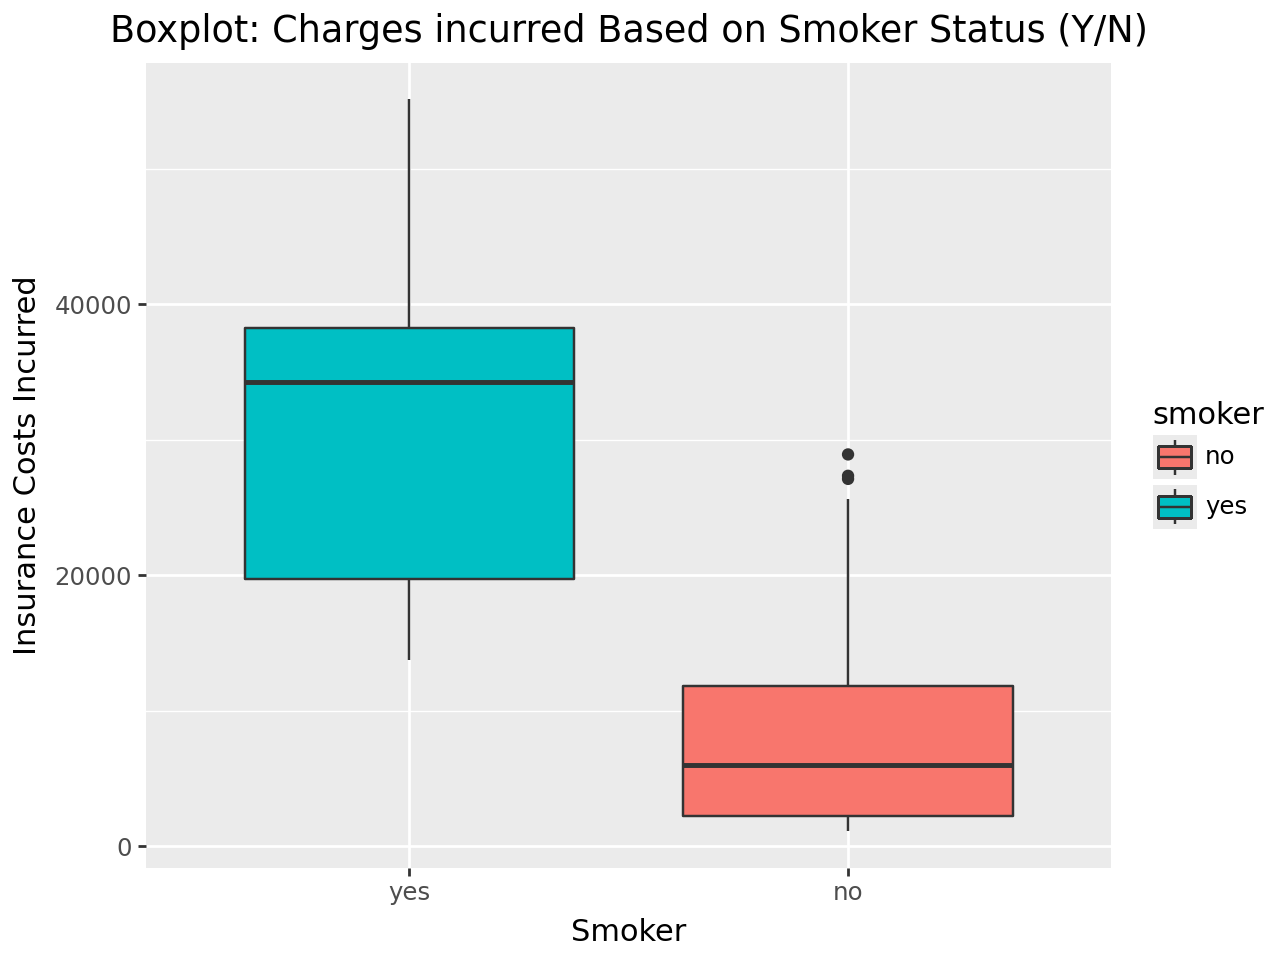

In [94]:
ggplot(df, aes(x='smoker', y='charges', fill='smoker')) + geom_boxplot() + labs(x="Smoker", y="Insurance Costs Incurred", title = "Boxplot: Charges incurred Based on Smoker Status (Y/N)") + scale_x_discrete(limits=['yes','no'])

Smokers have substantially higher median insurance charges than non-smokers, so smoker status is likely to be an important predictor.

### Incured costs for women are highest in the southeast compared to men who peak in the southwest

I chose a side-by-side bar chart because I wanted to see a clear comparison between the regions and average costs incured. I can see geography appears to change cost patterns.

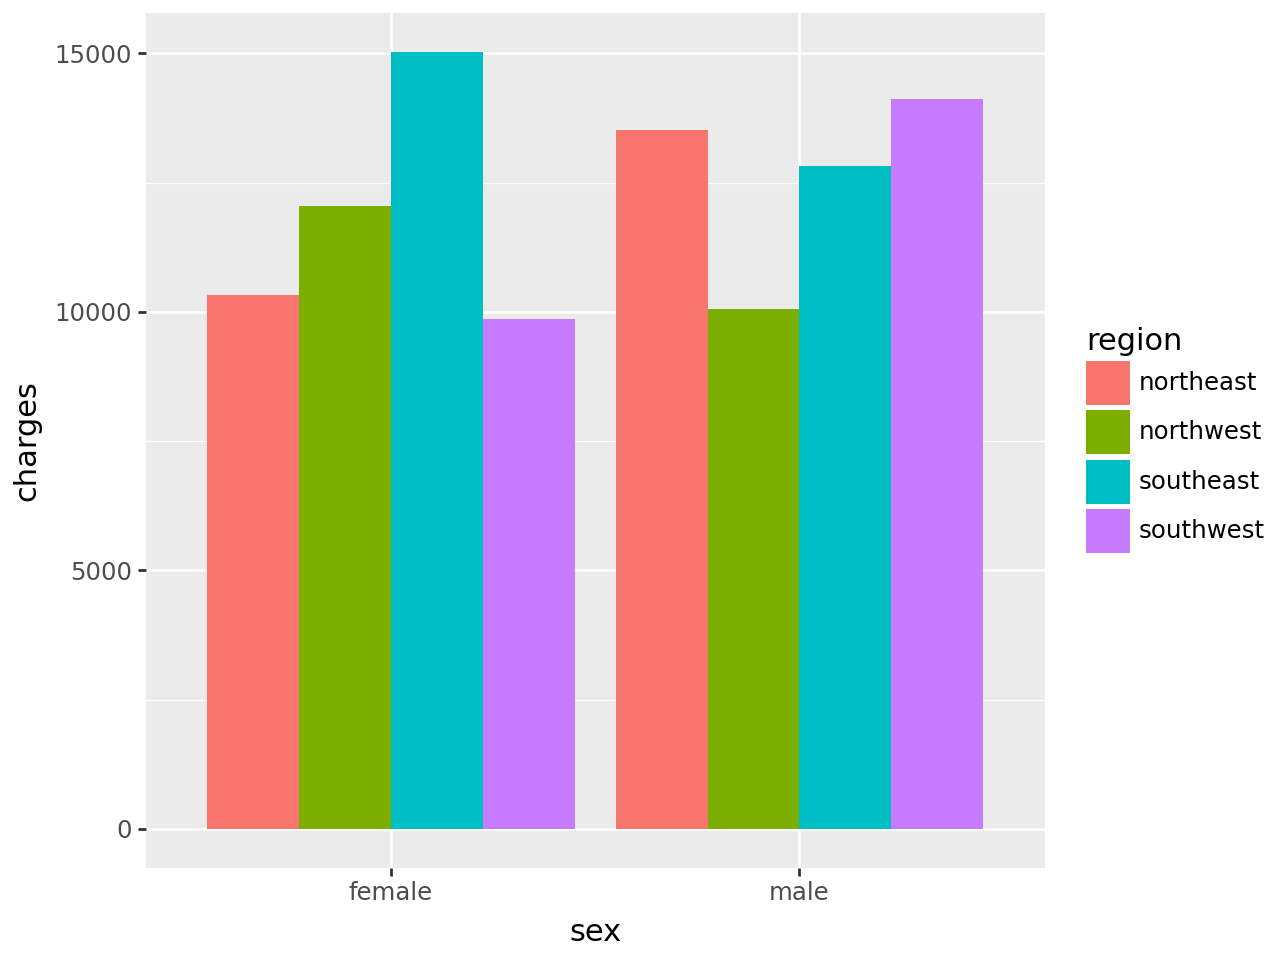

In [95]:
df_mean = df.groupby(['sex','region'], as_index=False)['charges'].mean()
ggplot(df_mean, aes(x='sex', y='charges', fill='region')) + geom_col(position='dodge')



### Higher BMI is generally associated with higher insurance charges across both sexes

I used a Scatterplot to capture the relationship between BMI, sex, and costs and find clusters or outliers. Based on this graph, both groups have higher costs for individuals with higher BMI and there were no distinctive differences between sexes.

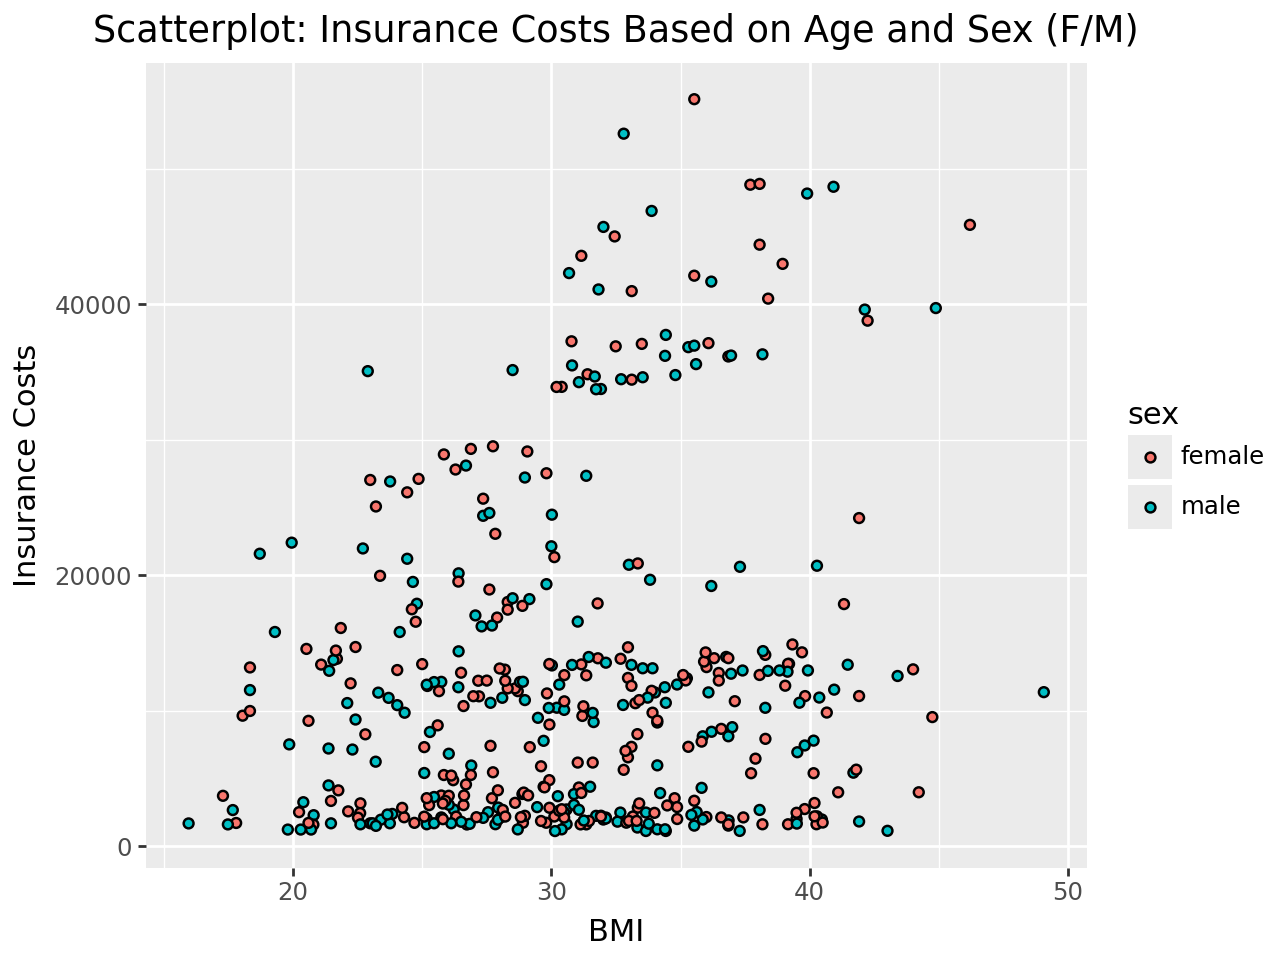

In [96]:
ggplot(df, aes(x='bmi', y='charges', fill='sex')) + geom_point() + labs(x='BMI', y='Insurance Costs', title='Scatterplot: Insurance Costs Based on Age and Sex (F/M)')

BMI has a positive relationship with insurance charges, meaning higher BMI is generally associated with higher medical costs. The pattern looks linear, so I started with linear regression.



## Simple Linear Regression Models

In [97]:
X = df[['age']]
y = df['charges']

lr_linear = LinearRegression()
lr_linear.fit(X, y)

y_pred = lr_linear.predict(X)

linear_mse = mean_squared_error(y, y_pred)
linear_rmse = np.sqrt(linear_mse)

pd.DataFrame({
    'Metric': ['Mean Squared Error (MSE)', 'Root Mean Squared Error (RMSE)', 'Intercept', 'Slope', 'R-squared'],
    'Value': [linear_mse, linear_rmse, lr_linear.intercept_, lr_linear.coef_[0], lr_linear.score(X, y)]
})

,Metric,Value
0,Mean Squared Error (MSE),1.269406e+08
1,Root Mean Squared Error (RMSE),1.126679e+04
2,Intercept,3.666219e+03
3,Slope,2.277528e+02
4,R-squared,9.835064e-02


The simple age model shows a positive relationship between age and insurance charges. The slope means expected charges increase by about $228 for each additional year of age.

The R-squared value is low, so age alone explains only a small share of the variation in insurance charges. I use this model as a baseline rather than as the final model.

In [98]:
df_sex = pd.get_dummies(df, columns=['sex'], drop_first=True)

X = df_sex[['age', 'sex_male']]
y = df_sex['charges']

lr_sex = LinearRegression()
lr_sex.fit(X, y)

predictions = lr_sex.predict(X)

mse_value = mean_squared_error(y, predictions)
rmse = np.sqrt(mse_value)

pd.DataFrame({
    'Metric': ['Features', 'Intercept', 'Coefficient (age)', 'Coefficient (sex_male)', 'R-squared', 'MSE', 'RMSE'],
    'Value': ['Age + Sex', lr_sex.intercept_, lr_sex.coef_[0], lr_sex.coef_[1], lr_sex.score(X, y), mse_value, rmse]
})

,Metric,Value
0,Features,Age + Sex
1,Intercept,3357.733786
2,Coefficient (age),227.30016
3,Coefficient (sex_male),683.146225
4,R-squared,0.099177
5,MSE,126824266.070508
6,RMSE,11261.628038


The model using age and smoker status performs much better than the model using age and sex. Its MSE is much lower and its R-squared is much higher, which indicates that smoker status explains a large amount of variation in insurance charges while sex adds very little predictive value here.

In [99]:
df_smoker = pd.get_dummies(df, columns=['smoker'], drop_first=True)

X = df_smoker[['age', 'smoker_yes']]
y = df_smoker['charges']

lr_smoker = LinearRegression()
lr_smoker.fit(X, y)

predictions = lr_smoker.predict(X)

mse_val = mean_squared_error(y, predictions)
rmse = np.sqrt(mse_val)

pd.DataFrame({
    'Metric': ['Features', 'Intercept', 'Coefficient (age)', 'Coefficient (smoker_yes)', 'R-squared', 'MSE', 'RMSE'],
    'Value': ['Age + Smoker', lr_smoker.intercept_, lr_smoker.coef_[0], lr_smoker.coef_[1], lr_smoker.score(X, y), mse_val, rmse]
})

,Metric,Value
0,Features,Age + Smoker
1,Intercept,-2157.425806
2,Coefficient (age),252.975856
3,Coefficient (smoker_yes),24045.648149
4,R-squared,0.75995
5,MSE,33795894.025218
6,RMSE,5813.423606


## Multiple Linear Regression Models

Next, I compare models that include BMI, smoker status, and interaction terms. I use MSE because this is a regression problem and prediction distance matters: larger errors should be penalized more heavily.

Adding BMI to the age-only model modestly improves performance. The age-only model has an MSE of about 126,940,631 and an R-squared of 0.098, while the age + BMI model has a lower MSE of about 123,981,358 and a higher R-squared of 0.119. This means BMI adds some predictive value, but the improvement is still limited, so I continue comparing additional model forms.

In [100]:
X_age_bmi = df[['age', 'bmi']]
y_age_bmi = df['charges']

model_age_bmi = LinearRegression()
model_age_bmi.fit(X_age_bmi, y_age_bmi)

y_pred_age_bmi = model_age_bmi.predict(X_age_bmi)

mse_age_bmi = mean_squared_error(y_age_bmi, y_pred_age_bmi)
r2_age_bmi = model_age_bmi.score(X_age_bmi, y_age_bmi)

pd.DataFrame({
    'Metric': ['Features', 'Intercept', 'Coefficient (age)', 'Coefficient (bmi)', 'MSE (Age + BMI)', 'R-squared (Age + BMI)'],
    'Value': ['Age + BMI', model_age_bmi.intercept_, model_age_bmi.coef_[0], model_age_bmi.coef_[1], mse_age_bmi, r2_age_bmi]
})

,Metric,Value
0,Features,Age + BMI
1,Intercept,-4579.374681
2,Coefficient (age),215.208034
3,Coefficient (bmi),283.475658
4,MSE (Age + BMI),123981357.756336
5,R-squared (Age + BMI),0.11937


### Polynomial Regression

I also test polynomial age models to check whether a curved relationship improves performance. I only use this after the linear baseline because the scatterplots do not suggest a highly complex nonlinear pattern.

In [101]:
df['age_sq'] = df['age'] ** 2

X_quad = df[['age', 'age_sq']]
y_quad = df['charges']

model_quad = LinearRegression()
model_quad.fit(X_quad, y_quad)

y_quad_pred = model_quad.predict(X_quad)

mse_quad = mean_squared_error(y_quad, y_quad_pred)
r2_quad = model_quad.score(X_quad, y_quad)

pd.DataFrame({
    'Metric': ['Features', 'Intercept', 'Coefficient (age)', 'Coefficient (age_sq)', 'MSE (Quadratic)', 'R-squared (Quadratic)'],
    'Value': ['Age + Age²', model_quad.intercept_, model_quad.coef_[0], model_quad.coef_[1], mse_quad, r2_quad]
})

,Metric,Value
0,Features,Age + Age²
1,Intercept,2457.634908
2,Coefficient (age),301.050851
3,Coefficient (age_sq),-0.921575
4,MSE (Quadratic),126916091.595717
5,R-squared (Quadratic),0.098525


In [124]:
X = df[['age']]
y = df['charges']

poly4 = PolynomialFeatures(degree=4, include_bias=False)
model_deg4 = make_pipeline(poly4, LinearRegression())
model_deg4.fit(X, y)

y_pred_deg4 = model_deg4.predict(X)

mse_deg4 = mean_squared_error(y, y_pred_deg4)
r2_deg4 = model_deg4.score(X, y)

pd.DataFrame({
    'Metric': ['Feature', 'MSE', 'R-squared'],
    'Value': ['Age⁴', mse_deg4, r2_deg4]
})

,Metric,Value
0,Feature,Age⁴
1,MSE,125752238.88483
2,R-squared,0.106792


In [103]:
poly12 = PolynomialFeatures(degree=12, include_bias=False)
model_deg12 = make_pipeline(poly12, LinearRegression())
model_deg12.fit(X, y)

y_pred_deg12 = model_deg12.predict(X)

mse_deg12 = mean_squared_error(y, y_pred_deg12)
r2_deg12 = model_deg12.score(X, y)

pd.DataFrame({
    'Metric': ['Model', 'MSE', 'R-squared'],
    'Value': ['Polynomial Degree 12', mse_deg12, r2_deg12]
})

,Metric,Value
0,Model,Polynomial Degree 12
1,MSE,125817853.669204
2,R-squared,0.106326


The degree 4 polynomial has a slightly lower MSE than the degree 12 polynomial, but the difference is small. I would prefer the simpler model unless a more complex curve clearly improves prediction on new data.

c:\Users\aniru\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
c:\Users\aniru\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names


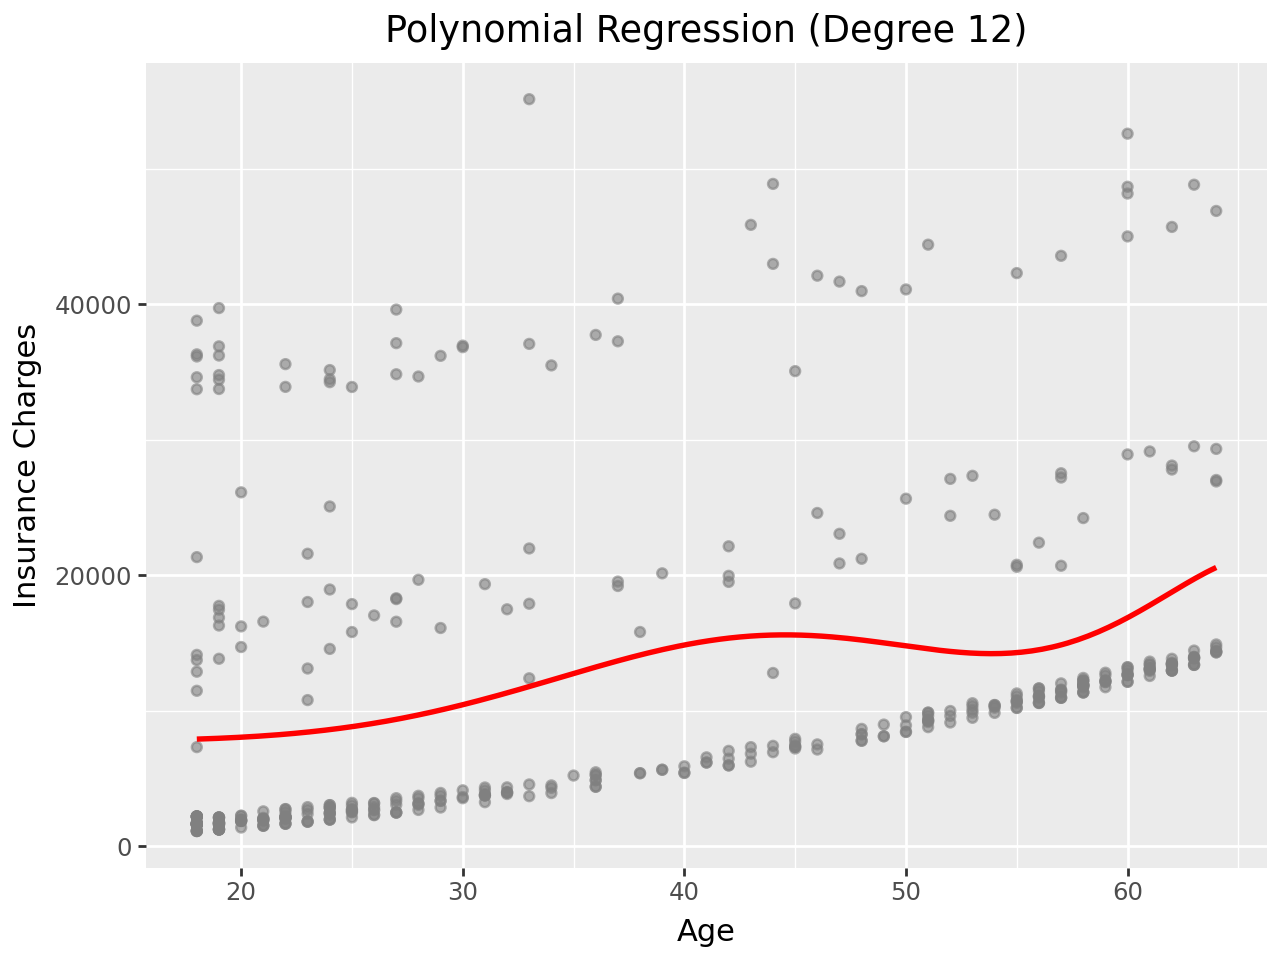

In [104]:
x_pred = np.linspace(df['age'].min(), df['age'].max(), 200).reshape(-1, 1)
X_pred_poly12 = poly12.transform(x_pred)
y_pred_poly12 = model_deg12.predict(x_pred)

reg12_df = pd.DataFrame({'age': x_pred.flatten(), 'charges_pred': y_pred_poly12})

(ggplot(df, aes(x='age', y='charges')) + geom_point(alpha=0.6, color='gray') + geom_line(reg12_df, aes(x='age', y='charges_pred'), color='red', size=1.1) + labs(title="Polynomial Regression (Degree 12)", x="Age", y="Insurance Charges"))

## New Data Evaluation

I used a new insurance dataset to compare how the fitted models generalize beyond the original sample.

In [105]:
df_new = pd.read_csv("insurance_costs_2.csv")

from sklearn.model_selection import train_test_split

### Combined Data Preparation

I combined the original and new dataset to make a final model using the same model data preparations as the training set.

In [106]:
df_combined = pd.concat([df, df_new], ignore_index=True)
df_encoded = pd.get_dummies(df_combined, columns=['smoker'], drop_first=True)

df_encoded['age_smoker'] = df_encoded['age'] * df_encoded['smoker_yes']
df_encoded['bmi_smoker'] = df_encoded['bmi'] * df_encoded['smoker_yes']

y = df_encoded['charges']
X = df_encoded[['age', 'bmi', 'smoker_yes', 'age_smoker', 'bmi_smoker']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

### Baseline Model: Age

This model uses age as a feature and serves as the simplest benchmark.

In [107]:
model = LinearRegression()
model.fit(X_train[['age']], y_train)
y_pred = model.predict(X_test[['age']])

pd.DataFrame({
    'Metric': ['Feature', 'Train R²', 'Test R²', 'Test MSE'],
    'Value': ['Age', model.score(X_train[['age']], y_train), model.score(X_test[['age']], y_test), mean_squared_error(y_test, y_pred)]
})

,Metric,Value
0,Feature,Age
1,Train R²,0.115632
2,Test R²,0.071178
3,Test MSE,137892826.357926


### Age and BMI Model

This model adds BMI to age because the exploratory scatterplot suggested that BMI is related to insurance charges.

In [118]:
X = df_encoded[['age', 'bmi']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

model_age_bmi = LinearRegression()
model_age_bmi.fit(X_train, y_train)

y_pred = model_age_bmi.predict(X_test)

train_r2 = model_age_bmi.score(X_train, y_train)
test_r2 = model_age_bmi.score(X_test, y_test)
mse = mean_squared_error(y_test, y_pred)

pd.DataFrame({
    'Metric': ['Features', 'Train R²', 'Test R²', 'Test MSE', 'Intercept', 'Coefficient (age)', 'Coefficient (bmi)'],
    'Value': ['Age + BMI', train_r2, test_r2, mse, model_age_bmi.intercept_, model_age_bmi.coef_[0], model_age_bmi.coef_[1]]
})

,Metric,Value
0,Features,Age + BMI
1,Train R²,0.134994
2,Test R²,0.098173
3,Test MSE,133885203.902679
4,Intercept,-5258.265513
5,Coefficient (age),240.591829
6,Coefficient (bmi),272.297017


### Age, BMI, and Smoker Model

This model adds smoker status because the boxplot showed a large cost difference between smokers and non-smokers.

In [123]:
X = df_encoded[['age', 'bmi', 'smoker_yes']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

model_age_bmi_smoker = LinearRegression()
model_age_bmi_smoker.fit(X_train, y_train)

y_pred = model_age_bmi_smoker.predict(X_test)

train_r2 = model_age_bmi_smoker.score(X_train, y_train)
test_r2 = model_age_bmi_smoker.score(X_test, y_test)
mse = mean_squared_error(y_test, y_pred)

pd.DataFrame({
    'Metric': ['Features', 'Train R²', 'Test R²', 'Test MSE', 'Intercept', 'Coefficient (age)', 'Coefficient (bmi)', 'Coefficient (smoker_yes)'],
    'Value': ['Age + BMI + Smoker', train_r2, test_r2, mse, model_age_bmi_smoker.intercept_, model_age_bmi_smoker.coef_[0], model_age_bmi_smoker.coef_[1], model_age_bmi_smoker.coef_[2]]
})

,Metric,Value
0,Features,Age + BMI + Smoker
1,Train R²,0.790971
2,Test R²,0.742023
3,Test MSE,38299248.386975
4,Intercept,-9938.315054
5,Coefficient (age),259.884697
6,Coefficient (bmi),242.804027
7,Coefficient (smoker_yes),24195.646378


### Interaction-Only Smoker Model

This model tests whether the effects of age and BMI differ by smoker status.

In [121]:
X = df_encoded[['age_smoker', 'bmi_smoker']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

model_interaction_only = LinearRegression()
model_interaction_only.fit(X_train, y_train)

y_pred = model_interaction_only.predict(X_test)

train_r2 = model_interaction_only.score(X_train, y_train)
test_r2 = model_interaction_only.score(X_test, y_test)
mse = mean_squared_error(y_test, y_pred)

pd.DataFrame({
    'Metric': ['Features', 'Train R²', 'Test R²', 'Test MSE'],
    'Value': ['(Age + BMI):Smoker (interaction only)', train_r2, test_r2, mse]
})

,Metric,Value
0,Features,(Age + BMI):Smoker (interaction only)
1,Train R²,0.731358
2,Test R²,0.674394
3,Test MSE,48339417.504207


### Main Effects and Smoker Interactions

This model keeps age, BMI, and smoker status while also allowing age and BMI to interact with smoker status.

In [111]:
y = df_encoded['charges']

features = {"Model 1: age": ["age"], "Model 2: age + bmi": ["age", "bmi"], "Model 3: age + bmi + smoker": ["age", "bmi", "smoker_yes"], "Model 4: (age + bmi):smoker": ["age_smoker", "bmi_smoker"], "Model 5: (age + bmi)*smoker": ["age", "bmi", "smoker_yes", "age_smoker", "bmi_smoker"]}

results = []

for name, cols in features.items():
    X = df_encoded[cols]
    model = LinearRegression().fit(X, y)
    y_pred = model.predict(X)
    mse = mean_squared_error(y, y_pred)
    r2 = model.score(X, y)
    results.append([name, mse, r2])

In [112]:
results_df = pd.DataFrame(results, columns=["Model", "MSE (new data)", "R² (new data)"])

results_df["MSE (new data)"] = results_df["MSE (new data)"].apply(lambda x: f"{x:,.2f}")
results_df["R² (new data)"] = results_df["R² (new data)"].round(3)

results_df

,Model,MSE (new data),R² (new data)
0,Model 1: age,"129,201,372.67",0.105
1,Model 2: age + bmi,"126,101,425.87",0.126
2,Model 3: age + bmi + smoker,"31,910,403.72",0.779
3,Model 4: (age + bmi):smoker,"40,835,923.30",0.717
4,Model 5: (age + bmi)*smoker,"19,420,367.28",0.865


In [113]:
new_results = []

df_new_encoded = pd.get_dummies(df_new, columns=['smoker'], drop_first=True)
df_new_encoded['age_smoker'] = df_new_encoded['age'] * df_new_encoded['smoker_yes']
df_new_encoded['bmi_smoker'] = df_new_encoded['bmi'] * df_new_encoded['smoker_yes']

for name, cols in features.items():
    X_train_m = df_encoded.loc[X_train.index, cols]
    X_test_new = df_new_encoded[cols]
    
    model = LinearRegression()
    model.fit(X_train_m, y_train)
    
    y_new_pred = model.predict(X_test_new)
    
    mse_new = mean_squared_error(df_new_encoded['charges'], y_new_pred)
    r2_new = model.score(X_test_new, df_new_encoded['charges'])
    
    new_results.append([name, f"{mse_new:,.2f}", round(r2_new, 3)])

new_results_df = pd.DataFrame(new_results, columns=["Model", "MSE (new data)", "R² (new data)"])
new_results_df

,Model,MSE (new data),R² (new data)
0,Model 1: age,"135,766,924.13",0.124
1,Model 2: age + bmi,"132,200,534.19",0.147
2,Model 3: age + bmi + smoker,"34,869,408.34",0.775
3,Model 4: (age + bmi):smoker,"47,367,033.81",0.695
4,Model 5: (age + bmi)*smoker,"21,644,075.56",0.860


In [114]:
new_results_df = pd.DataFrame(new_results, columns=["Model", "MSE (new data)", "R² (new data)"])
new_results_df

,Model,MSE (new data),R² (new data)
0,Model 1: age,"135,766,924.13",0.124
1,Model 2: age + bmi,"132,200,534.19",0.147
2,Model 3: age + bmi + smoker,"34,869,408.34",0.775
3,Model 4: (age + bmi):smoker,"47,367,033.81",0.695
4,Model 5: (age + bmi)*smoker,"21,644,075.56",0.860


### Residual Diagnostics

I plotted the residuals against the predicted charges to see how well the model performed.

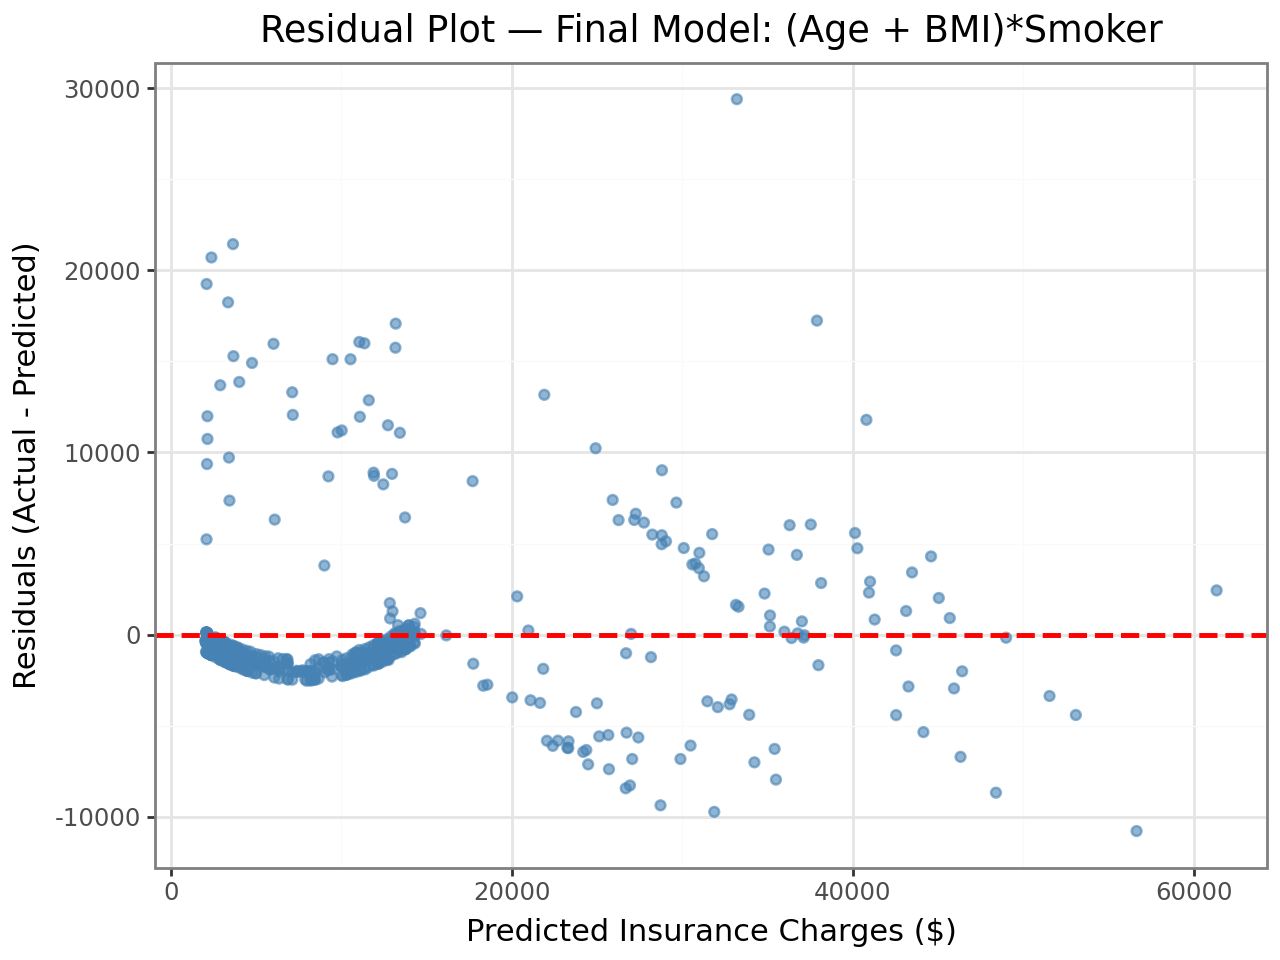

In [115]:
final_features = ['age', 'bmi', 'smoker_yes', 'age_smoker', 'bmi_smoker']

X_final = df_encoded[final_features]
y_final = df_encoded['charges']

final_model = LinearRegression()
final_model.fit(X_final, y_final)

y_pred_final = final_model.predict(X_final)
df_encoded['residuals'] = y_final - y_pred_final
df_encoded['predicted'] = y_pred_final

(ggplot(df_encoded, aes(x='predicted', y='residuals')) + geom_point(alpha=0.6, color='steelblue') + geom_hline(yintercept=0, color='red', linetype='dashed', size=1) + labs(title="Residual Plot — Final Model: (Age + BMI)*Smoker", x="Predicted Insurance Charges ($)", y="Residuals (Actual - Predicted)") + theme_bw())

## Final Model Evaluation

I compared the candidate models using MSE and R-squared on the new data. The best model is the one that reduces prediction error while still making practical sense for the insurance cost problem.


,Degree,MSE,R²
0,1,3.547205e+07,0.771222
1,2,2.155054e+07,0.861009
2,3,2.206654e+07,0.857681
3,4,2.535740e+07,0.836456
4,5,3.078418e+07,0.801456


,Best Degree
0,2


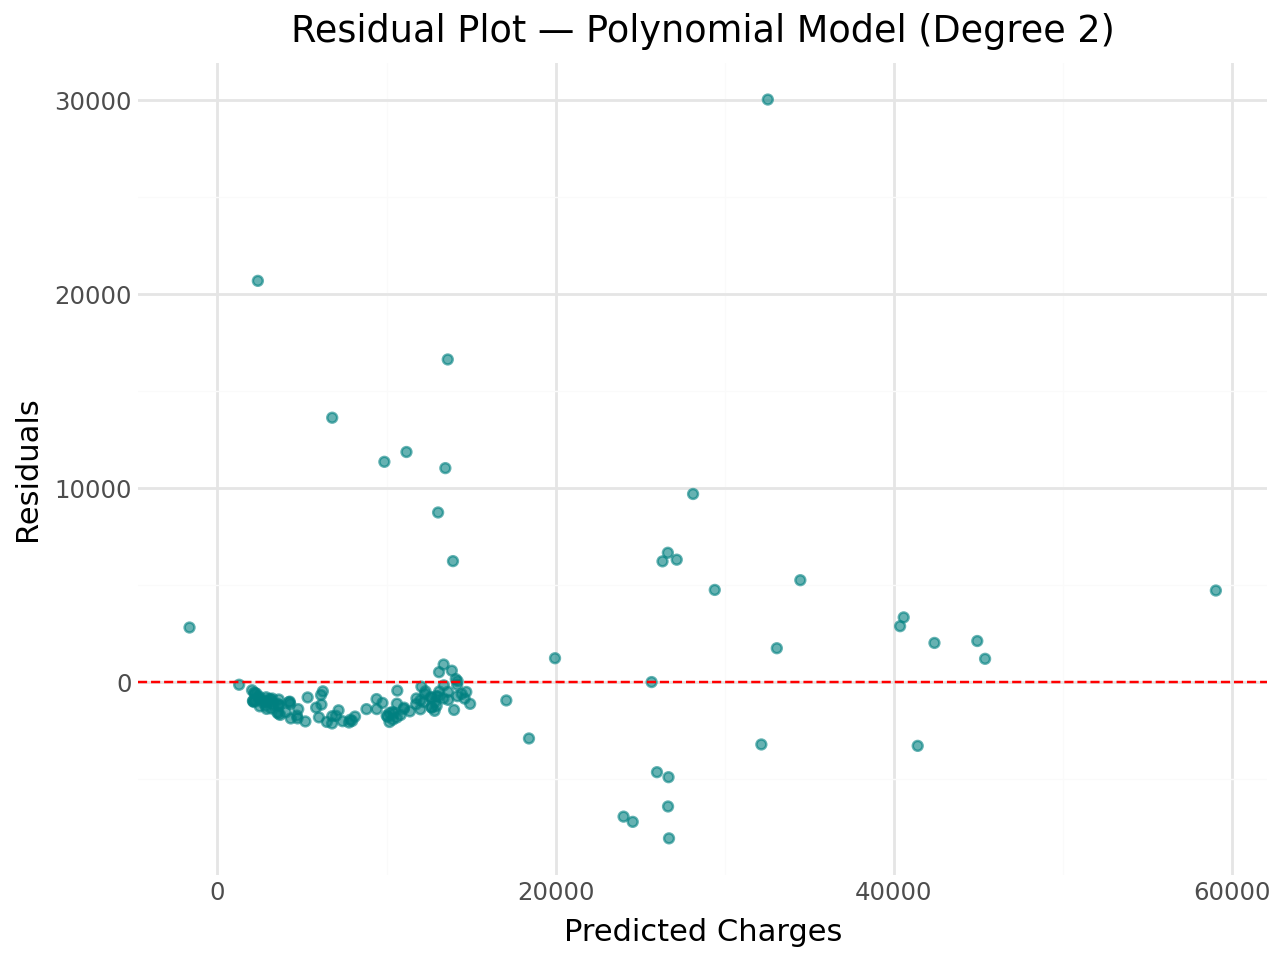

In [116]:
df['smoker_yes'] = (df['smoker'] == 'yes').astype(int)
df_new['smoker_yes'] = (df_new['smoker'] == 'yes').astype(int)
df['male'] = (df['sex'] == 'male').astype(int)
df_new['male'] = (df_new['sex'] == 'male').astype(int)

features = ['age', 'bmi', 'smoker_yes', 'male']

results = []
for d in range(1, 6):
    poly = PolynomialFeatures(degree=d, include_bias=False)
    X_train = poly.fit_transform(df[features])
    X_test = poly.transform(df_new[features])
    model = LinearRegression().fit(X_train, df['charges'])
    y_pred = model.predict(X_test)
    mse = mean_squared_error(df_new['charges'], y_pred)
    r2 = r2_score(df_new['charges'], y_pred)
    results.append((d, mse, r2))

results_df = pd.DataFrame(results, columns=['Degree', 'MSE', 'R²'])
display(results_df)

best_degree = results_df.loc[results_df['MSE'].idxmin(), 'Degree']
display(pd.DataFrame({'Best Degree': [int(best_degree)]}))

poly = PolynomialFeatures(degree=int(best_degree), include_bias=False)
X_train = poly.fit_transform(df[features])
X_test = poly.transform(df_new[features])
model = LinearRegression().fit(X_train, df['charges'])
y_pred = model.predict(X_test)

residuals_df = pd.DataFrame({'predicted': y_pred, 'residuals': df_new['charges'] - y_pred})
(ggplot(residuals_df, aes(x='predicted', y='residuals')) + geom_point(alpha=0.6, color='teal') + geom_hline(yintercept=0, color='red', linetype='dashed') + labs(title=f'Residual Plot — Polynomial Model (Degree {int(best_degree)})', x='Predicted Charges', y='Residuals') + theme_minimal())

Among the linear and interaction models, the main effects plus smoker interactions model performs best on the new data, with an MSE of about 21,644,076 and an R-squared of 0.860. In the final polynomial comparison, the degree 2 model performs slightly better, with an MSE of about 21,550,540 and an R-squared of 0.861. I would choose the degree 2 model based on MSE because it has the lowest prediction error on the new data, while still fitting the mostly smooth relationship shown in the earlier plots.